# Model Inference

This notebook demonstrates pneumonia prediction using the trained MobileNetV2 model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/Pneumonia_CDSS_Project/mobilenetv2_original.keras"

model = load_model(MODEL_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
import os

TEST_PNEUMONIA_PATH = "/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/test/PNEUMONIA"

sample_image = os.path.join(
    TEST_PNEUMONIA_PATH,
    os.listdir(TEST_PNEUMONIA_PATH)[0]
)

print(sample_image)

/content/drive/MyDrive/archive (6)/chest_xray/chest_xray/test/PNEUMONIA/person100_bacteria_482.jpeg


In [4]:
import cv2
import numpy as np

img = cv2.imread(sample_image)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img_rgb,
    (160,160)
)

img_array = img_resized.astype("float32") / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

print(img_array.shape)

(1, 160, 160, 3)


In [5]:
prediction = model.predict(img_array)

score = prediction[0][0]

print("Prediction Score:", score)

if score > 0.5:
    print("Predicted Class: PNEUMONIA")
else:
    print("Predicted Class: NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Prediction Score: 0.9998503
Predicted Class: PNEUMONIA


In [6]:
print(
    f"Confidence: {score*100:.2f}%"
)

Confidence: 99.99%


# Prediction Result

The trained MobileNetV2 model predicts whether the uploaded chest X-ray belongs to the Normal or Pneumonia class.

The prediction confidence score indicates the model's certainty regarding the classification result.

In [7]:
if score > 0.8:
    recommendation = (
        "High Risk - Immediate Clinical Review Recommended"
    )

elif score > 0.5:
    recommendation = (
        "Moderate Risk - Further Investigation Required"
    )

else:
    recommendation = (
        "Low Risk - No Pneumonia Detected"
    )

print(recommendation)

High Risk - Immediate Clinical Review Recommended


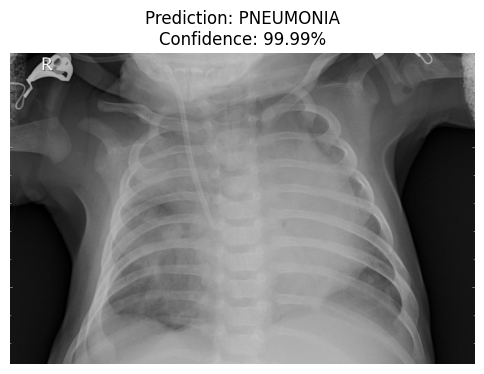

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(img_rgb)

plt.axis("off")

plt.title(
    f"Prediction: {'PNEUMONIA' if score > 0.5 else 'NORMAL'}\n"
    f"Confidence: {score*100:.2f}%"
)

plt.show()

# Clinical Decision Support Demonstration

The trained MobileNetV2 model successfully analyzed a chest X-ray image and generated:

- Disease prediction
- Confidence score
- Clinical risk recommendation

This notebook demonstrates the inference pipeline that will be integrated into the deployment dashboard.

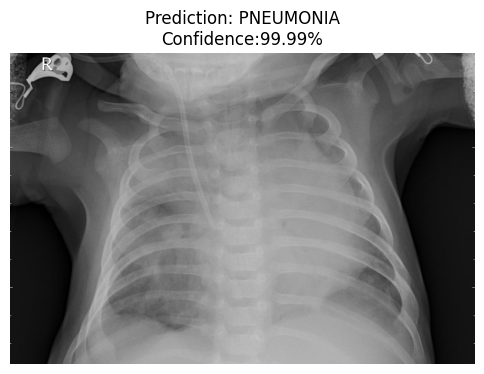

In [9]:
plt.figure(figsize=(6,6))

plt.imshow(img_rgb)

plt.axis("off")

plt.title(
    f"Prediction: PNEUMONIA\nConfidence:{score*100:.2f}%"
)

plt.savefig(
    "/content/drive/MyDrive/Pneumonia_CDSS_Project/outputs/sample_prediction.png"
)

plt.show()

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "MobileNetV2",
        "MobileNetV2 + Augmentation"
    ],
    "Accuracy (%)": [62.5, 79.8, 89.3],
    "Pneumonia Recall": [1.00, 0.99, 0.87],
    "False Negatives": [0, 2, 50]
})

comparison

,Model,Accuracy (%),Pneumonia Recall,False Negatives
0,Baseline CNN,62.5,1.00,0
1,MobileNetV2,79.8,0.99,2
2,MobileNetV2 + Augmentation,89.3,0.87,50


In [11]:
comparison.to_csv(
    "/content/drive/MyDrive/Pneumonia_CDSS_Project/outputs/model_comparison.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
